# Multipole-range API: dipole and monopole (Fisher-driven)

This notebook demonstrates the *physics* of the new ``lmin_signal``
/ ``lmin`` / ``lmax`` / ``lmax_signal`` controls (ADR 0009) using the
production ``qube.Fisher`` / ``qube.Spectra`` pipeline — no
hand-rolled QML estimator. Both demos follow the same recipe:

1. Generate masked CMB maps with a known low-ℓ component.
2. Run ``Fisher`` + ``Spectra`` with the legacy convention
   (``lmin=2``, no monopole/dipole modelled) — power at the
   excluded multipoles mask-couples into the lowest inferred
   bandpowers and biases them.
3. Run with the standard practitioner workarounds: fit-and-subtract
   monopole/dipole on the *masked* pixels, or on the *full sky*
   before masking. Show that the masked-first version is biased
   (the templates aren't orthogonal to ℓ≥2 $Y_{\ell m}$ on a
   partial sky) while the full-sky-first version is clean.
4. Run with the new convention (``lmin_signal=0/1`` and ``lmin``
   extended down). Confirm it matches the full-sky-first variant
   and removes the bias without requiring trust in the masked
   region.

The point is to make the reader fluent in *why* extending the
inference window matters and *when* the simpler healpy workarounds
are or aren't equivalent.


In [1]:
import os
import shutil
import tempfile

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml

from qube import Fisher, Spectra

rng = np.random.default_rng(20260508)
plt.rcParams["figure.dpi"] = 110

## Geometry — partial-sky T mask

We work at ``nside=8`` with a galactic-cut mask covering ~55 % of the
sky. The mask is what couples ℓ=1 power into ℓ=2,3,…; on the full
sphere the $Y_{\ell m}$ are orthonormal and there is no leakage at
all.


nside=8  n_pix=416  f_sky=0.54


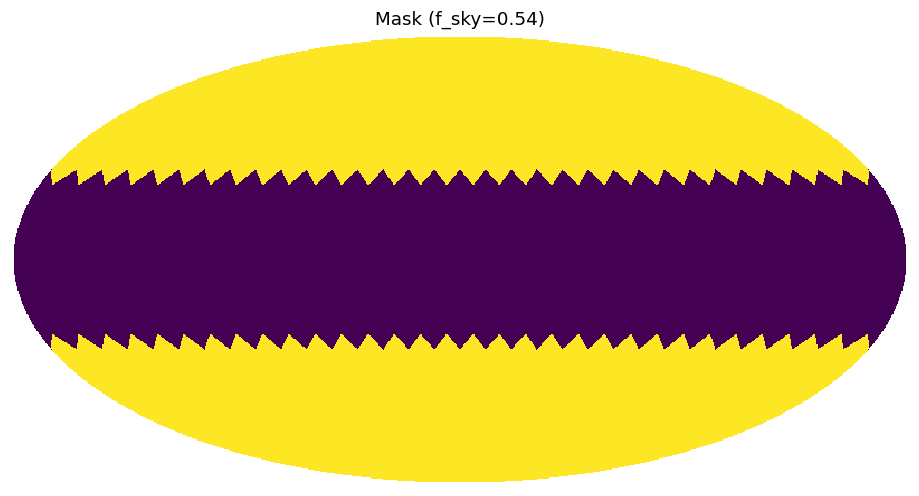

In [2]:
NSIDE = 8
LMAX_SIGNAL = 4 * NSIDE  # 32
N_PIX_FULL = hp.nside2npix(NSIDE)

theta_full, phi_full = hp.pix2ang(NSIDE, np.arange(N_PIX_FULL))
b_lat = np.pi / 2 - theta_full
mask = (np.abs(b_lat) > np.deg2rad(25)).astype(np.float64)
n_pix = int(mask.sum())
fsky = n_pix / N_PIX_FULL

print(f"nside={NSIDE}  n_pix={n_pix}  f_sky={fsky:.2f}")
hp.mollview(mask, title=f"Mask (f_sky={fsky:.2f})", cbar=False)
plt.show()

## Configuration helper

``run_estimator`` writes the inputs that QUBE expects (mask, noise
covmat, fiducial cls, simulation cube, YAML config) to a temporary
directory, runs ``Fisher`` + ``Spectra``, and returns the per-sim
bandpowers and the Fisher-predicted error bars. Everything below
funnels through this helper.


In [3]:
NSIMS = 100
NOISE_LEVEL = 1.0e-4
NOISE_VAR = NOISE_LEVEL**2


def _write_cls(path: str, cls_dict: dict[str, np.ndarray]) -> None:
    """Write a CAMB-style file with explicit ``ell`` column."""
    labels = ["ell", *cls_dict.keys()]
    n_out = next(iter(cls_dict.values())).shape[0]
    rows = np.zeros((n_out, len(labels)), dtype=np.float64)
    rows[:, 0] = np.arange(n_out)
    for j, label in enumerate(cls_dict, start=1):
        rows[:, j] = cls_dict[label]
    with open(path, "w") as f:
        f.write("# " + "  ".join(labels) + "\n")
        for row in rows:
            f.write("  ".join(f"{v:.16e}" for v in row) + "\n")


def synthesise_maps(cl_total: np.ndarray, *, n_sims: int, seed: int) -> np.ndarray:
    """Generate full-sky T maps from ``cl_total`` and add white noise."""
    rng = np.random.default_rng(seed)
    sims = np.empty((1, N_PIX_FULL, n_sims), dtype=np.float64)
    for s in range(n_sims):
        signal = hp.synfast(cl_total, NSIDE, lmax=LMAX_SIGNAL, new=True)
        noise = rng.normal(0.0, NOISE_LEVEL, size=N_PIX_FULL)
        sims[0, :, s] = signal + noise
    return sims


def run_estimator(
    *,
    sims: np.ndarray,
    cl_estimator: np.ndarray,
    cl_fiducial: np.ndarray | None,
    lmin_signal: int,
    lmin: int,
    lmax: int,
    lmax_signal: int = LMAX_SIGNAL,
    label: str = "T",
    spectrum_label: str = "TT",
):
    """Run Fisher + Spectra for one estimator configuration.

    Parameters
    ----------
    sims : (1, N_PIX_FULL, n_sims) array of T maps.
    cl_estimator : per-ell C_ell used by the estimator's S in C = N + S.
        Outside ``[lmin, lmax]`` the values are ignored — the high/low
        bands come from ``cl_fiducial`` via S_fixed.
    cl_fiducial : per-ell C_ell that populates ``S_fixed`` for
        multipoles in ``[lmin_signal, lmin)`` and
        ``(lmax, lmax_signal]``. ``None`` skips ``S_fixed`` entirely
        (the estimator carries no fiducial outside the inference
        window).
    lmin_signal, lmin, lmax, lmax_signal : the four ADR 0009 knobs.
    label : map label ("T" only here).
    """
    tmpdir = tempfile.mkdtemp(prefix="lmin_demo_")
    try:
        mask_path = os.path.join(tmpdir, "mask.fits")
        hp.write_map(mask_path, mask, overwrite=True, dtype=np.float64)

        cov_reduced = np.eye(n_pix, dtype=np.float64) * NOISE_VAR
        cov_path = os.path.join(tmpdir, "ncvm.bin")
        cov_reduced.tofile(cov_path)

        cls_path = os.path.join(tmpdir, "cls.dat")
        _write_cls(cls_path, {spectrum_label: cl_estimator})

        fiducial_path = None
        if cl_fiducial is not None:
            fiducial_path = os.path.join(tmpdir, "cls_fid.dat")
            _write_cls(fiducial_path, {spectrum_label: cl_fiducial})

        # Full-sky cube on disk: read_maps indexes by full-sky pixel ids.
        sim_path = os.path.join(tmpdir, "sims.npy")
        np.save(sim_path, sims)

        config = {
            "nside": NSIDE,
            "spins": [0],
            "labels": [label],
            "physical_labels": [label],
            "do_cross": False,
            "maskfile": mask_path,
            "output_geometry_file": os.path.join(tmpdir, "geometry.dat"),
            "ordering": "RING",
            "inputclfile": cls_path,
            "input_convention": "Cl",
            "covmatfile1": cov_path,
            "covmatfile2": cov_path,
            "lmax": lmax,
            "lmin": lmin,
            "lmax_signal": lmax_signal,
            "lmin_signal": [lmin_signal],
            "load_reduced": True,
            "load_inverted": False,
            "calibration": 1.0,
            "smoothing_type": "none",
            "fwhmarcmin": 0.0,
            "apply_pixwin": False,
            "beam_file": "",
            "outnoisecovmat1": os.path.join(tmpdir, "reduced_ncvm1.bin"),
            "outnoisecovmat2": os.path.join(tmpdir, "reduced_ncvm2.bin"),
            "outinvcovmatfile1": os.path.join(tmpdir, "invcov1.bin"),
            "outinvcovmatfile2": os.path.join(tmpdir, "invcov2.bin"),
            "outfilefisher": os.path.join(tmpdir, "fisher.dat"),
            "feedback": 0,
            "nsims": sims.shape[2],
            "inputmapfile1": sim_path,
            "inputmapfile2": sim_path,
            "outcovmatfile": os.path.join(tmpdir, "cov.dat"),
            "outerrfile": os.path.join(tmpdir, "err.dat"),
            "remove_nb": True,
            "delta_ell": 1,
        }
        if fiducial_path is not None:
            config["fiducialfile"] = fiducial_path

        config_path = os.path.join(tmpdir, "config.yaml")
        with open(config_path, "w") as f:
            yaml.dump(config, f)

        # Harmonic basis exposes the S_fixed code path used by the
        # foreground demo; the dipole / monopole demos work either way
        # but we use the same setup for consistency.
        compression = {"method": "harmonic"}
        fisher = Fisher(config_path, compression=compression)
        fisher.run()
        spectra = Spectra(config_path, fisher=fisher, compression=compression)
        spectra.run()

        bandpowers = spectra.get_power_spectra()
        errors = fisher.get_error_bars()
        ells = np.arange(lmin, lmax + 1)
        return ells, bandpowers, errors
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)

## Truth spectrum and noise

We use a flat-ish $C_\ell \propto 1/[\ell(\ell+1)]$ for the
high-ℓ CMB plus knobs for the monopole, dipole, and a foreground
template. The white-noise level sits well below the signal so the
leakage is not swamped by noise variance.


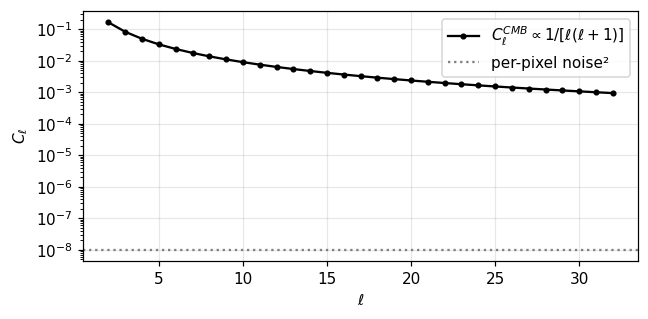

In [4]:
cl_cmb = np.zeros(LMAX_SIGNAL + 1)
for ell in range(2, LMAX_SIGNAL + 1):
    cl_cmb[ell] = 1.0 / (ell * (ell + 1))

ell_axis = np.arange(LMAX_SIGNAL + 1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(
    ell_axis[2:], cl_cmb[2:], "k-o", ms=3, label=r"$C_\ell^{CMB}\propto 1/[\ell(\ell+1)]$"
)
ax.axhline(NOISE_VAR, color="grey", ls=":", label="per-pixel noise²")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell$")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Demo 1 — dipole leakage on a masked sky

Inject a strong dipole on top of the CMB and run **four**
estimators:

1. **Legacy** (``lmin=2``, no dipole modelled): the QML basis cannot
   represent the dipole, so its power leaks into the lowest
   estimated multipoles.
2. **``hp.remove_dipole`` *on the masked pixels*, then ``lmin=2``**:
   the typical naive workaround. The (1, x̂, ŷ, ẑ) templates are
   *not* orthogonal to ℓ≥2 $Y_{\ell m}$ on a partial sky, so the
   fit absorbs ℓ≥2 power and the residual is biased *low*.
3. **``hp.remove_dipole`` *on the full sky* (before masking),
   then ``lmin=2``**: the clean version. On the full sphere
   (1, x̂, ŷ, ẑ) is exactly the ℓ=0,1 subspace, so the fit picks
   up only ℓ=0,1 power and leaves ℓ≥2 untouched. Should give
   nearly unbiased ℓ≥2 estimates (residual is rank-4 noise-cov
   mismatch — negligible for $n_\mathrm{pix} \gg 4$). Caveat:
   you have to trust the masked-region data for the full-sky fit
   to make sense.
4. **``lmin=1, lmin_signal=[1]``**: model the dipole directly. The
   estimator returns one extra bandpower for $C_1$ and the
   higher-ℓ bandpowers stay unbiased — no external clean-up step,
   no covariance distortion.


In [5]:
def remove_dipole_masked(sims_full_input: np.ndarray) -> np.ndarray:
    """Fit-and-subtract monopole + dipole on the *masked* pixels only.

    Embed the masked map full-sky with UNSEEN elsewhere, run
    hp.remove_dipole with ``bad=UNSEEN`` so the fit uses only unmasked
    pixels, then return the corrected full-sky cube. The (1, x̂, ŷ, ẑ)
    templates are *not* orthogonal to ℓ≥2 Y_ℓm on a partial sky, so the
    fit absorbs some ℓ≥2 power and the residual is biased.
    """
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    active = mask.astype(bool)
    for s in range(n_sims):
        full = np.full(N_PIX_FULL, hp.UNSEEN)
        full[active] = sims_full_input[0, active, s]
        corr = hp.remove_dipole(full, bad=hp.UNSEEN, copy=True)
        out[0, active, s] = corr[active]
    return out


def remove_dipole_fullsky(sims_full_input: np.ndarray) -> np.ndarray:
    """Fit-and-subtract monopole + dipole using the *full sphere*.

    This is the clean version: on the full sphere, (1, x̂, ŷ, ẑ) is
    exactly the ℓ=0,1 subspace, so the fit picks up only ℓ=0,1 power
    and leaves ℓ≥2 untouched. The residual noise covariance is
    perturbed by rank-4 (negligible when n_pix ≫ 4), so the QML on
    the masked residual is *nearly* unbiased on ℓ≥2. The downside is
    that the fit assumes the masked-region data is trustworthy —
    practitioners often don't.
    """
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    for s in range(n_sims):
        out[0, :, s] = hp.remove_dipole(sims_full_input[0, :, s], copy=True)
    return out


cl_true = cl_cmb.copy()
cl_true[1] = 5.0e-2  # large dipole

sims_full = synthesise_maps(cl_true, n_sims=NSIMS, seed=1)

# Legacy estimator: lmin=2, ignore dipole.
ells_l, bp_l, err_l = run_estimator(
    sims=sims_full,
    cl_estimator=cl_true,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# Workaround A: subtract dipole on the *masked* map (the bad way).
ells_h, bp_h, err_h = run_estimator(
    sims=remove_dipole_masked(sims_full),
    cl_estimator=cl_true,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# Workaround B: subtract dipole on the *full-sky* map *before* masking.
ells_f, bp_f, err_f = run_estimator(
    sims=remove_dipole_fullsky(sims_full),
    cl_estimator=cl_true,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# New convention: lmin=lmin_signal=1.
ells_d, bp_d, err_d = run_estimator(
    sims=sims_full,
    cl_estimator=cl_true,
    cl_fiducial=None,
    lmin_signal=1,
    lmin=1,
    lmax=8,
)

2026-05-08 14:21:06 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.13s


2026-05-08 14:21:06 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.10s


2026-05-08 14:21:07 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.09s


2026-05-08 14:21:07 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.11s


Bias (mean − truth) / truth:
   ell      legacy   hp_masked   hp_fullsky      lmin=1
     2       -4.0%      -30.5%        -3.9%       -4.0%
     3      +51.8%      -40.8%       +13.0%      +10.9%
     4      +13.4%      +22.8%       +13.3%      +13.4%
     5      +99.8%       +7.3%        -3.0%       -3.9%
     6       -4.8%       +1.4%        -4.8%       -4.8%


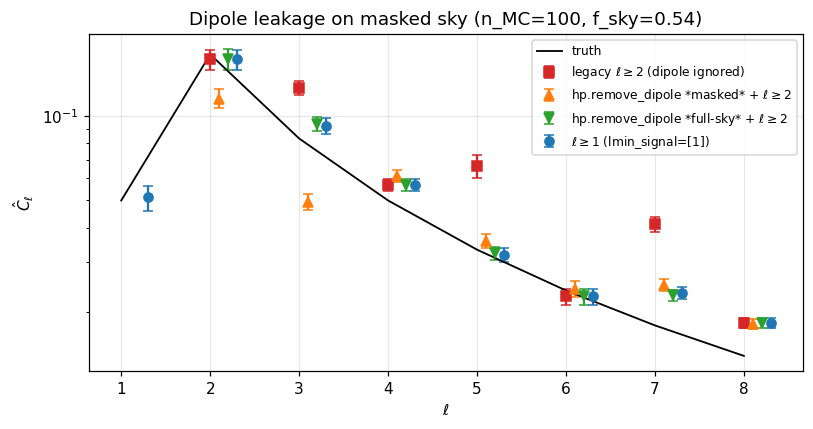

In [6]:
def _summary(bp: np.ndarray, err: np.ndarray):
    return bp.mean(axis=0), bp.std(axis=0, ddof=1) / np.sqrt(bp.shape[0]), err


m_l, se_l, _ = _summary(bp_l, err_l)
m_h, se_h, _ = _summary(bp_h, err_h)
m_f, se_f, _ = _summary(bp_f, err_f)
m_d, se_d, _ = _summary(bp_d, err_d)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.errorbar(
    ells_l,
    m_l,
    yerr=se_l,
    fmt="s",
    color="#d62728",
    label=r"legacy $\ell\geq 2$ (dipole ignored)",
    capsize=3,
)
ax.errorbar(
    ells_h + 0.10,
    m_h,
    yerr=se_h,
    fmt="^",
    color="#ff7f0e",
    label=r"hp.remove_dipole *masked* + $\ell\geq 2$",
    capsize=3,
)
ax.errorbar(
    ells_f + 0.20,
    m_f,
    yerr=se_f,
    fmt="v",
    color="#2ca02c",
    label=r"hp.remove_dipole *full-sky* + $\ell\geq 2$",
    capsize=3,
)
ax.errorbar(
    ells_d + 0.30,
    m_d,
    yerr=se_d,
    fmt="o",
    color="#1f77b4",
    label=r"$\ell\geq 1$ (lmin_signal=[1])",
    capsize=3,
)
ax.plot(ell_axis[1:9], cl_true[1:9], "k-", lw=1.2, label="truth")
ax.set_yscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\hat{C}_\ell$")
ax.set_title(f"Dipole leakage on masked sky (n_MC={NSIMS}, f_sky={fsky:.2f})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

print("Bias (mean − truth) / truth:")
print(
    f"  {'ell':>4s}  {'legacy':>10s}  {'hp_masked':>10s}  "
    f"{'hp_fullsky':>11s}  {'lmin=1':>10s}"
)
for ell in range(2, 7):
    i_l = list(ells_l).index(ell)
    i_h = list(ells_h).index(ell)
    i_f = list(ells_f).index(ell)
    i_d = list(ells_d).index(ell)
    legacy = (m_l[i_l] - cl_true[ell]) / cl_true[ell] * 100
    hp_m = (m_h[i_h] - cl_true[ell]) / cl_true[ell] * 100
    hp_f = (m_f[i_f] - cl_true[ell]) / cl_true[ell] * 100
    lmin1 = (m_d[i_d] - cl_true[ell]) / cl_true[ell] * 100
    print(
        f"  {ell:>4d}  {legacy:>+9.1f}%  {hp_m:>+9.1f}%  {hp_f:>+10.1f}%  {lmin1:>+9.1f}%"
    )

## Demo 2 — monopole leakage

Same logic, monopole instead of dipole. The intrinsic CMB monopole
is zero (rest frame), but a real T map carries a calibration offset,
foreground monopole, or any uniform additive contamination. With a
mask, that uniform offset is no longer orthogonal to higher-ℓ
$Y_{\ell m}$ — same leakage.

We run **six** variants. The first four are direct analogues of the
dipole demo; the next two test the common "be conservative — fit and
remove monopole *and* dipole even though I only injected a monopole"
choice (using ``hp.remove_dipole``, which fits the 4-D subspace
``{1, x̂, ŷ, ẑ}`` simultaneously):

1. **Legacy** ``lmin=2``, monopole ignored.
2. ``hp.remove_monopole`` *masked*, then ``lmin=2`` (biased — see
   note below).
3. ``hp.remove_dipole`` *masked* (mono+dipole), then ``lmin=2``.
   Worse than (2) because we project a 4-D subspace, none of whose
   vectors is ⊥ ℓ≥2 on a partial sky.
4. ``hp.remove_monopole`` *full-sky*, then ``lmin=2``. Clean: on
   the full sphere ``𝟙`` is exactly the ℓ=0 subspace.
5. ``hp.remove_dipole`` *full-sky* (mono+dipole), then ``lmin=2``.
   Also clean — full-sphere ``{1, x̂, ŷ, ẑ}`` is the ℓ=0,1
   subspace, both orthogonal to ℓ≥2. With no real dipole power
   present, removing the dipole costs a small amount of variance
   but introduces no bias.
6. ``lmin=0, lmin_signal=[0]``: model the monopole directly.

**On "dipoles popping up after masked-monopole removal":** the
operation ``d → d − c·𝟙`` only touches ``a₀₀`` — the harmonic
content for ℓ≥1 of the residual is identical to the input. What
*does* happen on a partial sky is that the masked-mean ``c`` is a
weighted sum over *all* ``a_ℓm`` (because the indicator function of
the mask is not pure ℓ=0), so subtracting ``c·𝟙`` and then running
QML with a model that assumes the un-projected covariance leaves a
rank-1 mismatch in ``Cov(d')``. That mismatch overlaps with ℓ≥2
``Y_ℓm`` modes — which the QML then attributes to bandpower bias.
The "dipole-shaped" appearance you might see in a Mollweide plot of
the residual is the mask geometry's own asymmetry, not new ℓ=1
power injected by the operation.


In [7]:
def remove_monopole_masked(sims_full_input: np.ndarray) -> np.ndarray:
    """Fit monopole on the *masked* pixels, subtract from full sky."""
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    active = mask.astype(bool)
    for s in range(n_sims):
        full = np.full(N_PIX_FULL, hp.UNSEEN)
        full[active] = sims_full_input[0, active, s]
        corr = hp.remove_monopole(full, bad=hp.UNSEEN, copy=True)
        out[0, active, s] = corr[active]
    return out


def remove_monopole_fullsky(sims_full_input: np.ndarray) -> np.ndarray:
    """Fit-and-subtract the monopole on the *full sphere*."""
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    for s in range(n_sims):
        out[0, :, s] = hp.remove_monopole(sims_full_input[0, :, s], copy=True)
    return out


def remove_dipole_masked(sims_full_input: np.ndarray) -> np.ndarray:
    """hp.remove_dipole on *masked* pixels — fits BOTH monopole + dipole."""
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    active = mask.astype(bool)
    for s in range(n_sims):
        full = np.full(N_PIX_FULL, hp.UNSEEN)
        full[active] = sims_full_input[0, active, s]
        corr = hp.remove_dipole(full, bad=hp.UNSEEN, copy=True)
        out[0, active, s] = corr[active]
    return out


def remove_dipole_fullsky(sims_full_input: np.ndarray) -> np.ndarray:
    """hp.remove_dipole on the *full sphere* — fits BOTH monopole + dipole."""
    n_sims = sims_full_input.shape[2]
    out = np.zeros_like(sims_full_input)
    for s in range(n_sims):
        out[0, :, s] = hp.remove_dipole(sims_full_input[0, :, s], copy=True)
    return out


cl_true_mono = cl_cmb.copy()
cl_true_mono[0] = 8.0e-2  # uniform offset / FG residual

sims_full = synthesise_maps(cl_true_mono, n_sims=NSIMS, seed=2)

ells_l, bp_l, err_l = run_estimator(
    sims=sims_full,
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# Monopole-only cleanup, masked-first vs full-sky-first.
ells_h, bp_h, err_h = run_estimator(
    sims=remove_monopole_masked(sims_full),
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)
ells_f, bp_f, err_f = run_estimator(
    sims=remove_monopole_fullsky(sims_full),
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# Conservative cleanup: remove BOTH monopole + dipole (hp.remove_dipole
# fits the 4-D subspace {1, x̂, ŷ, ẑ}). With no real dipole input, this
# shouldn't *help* over monopole-only — but it's a common practitioner
# choice, so we show what it does:
#  - full-sky-first: still clean (the 4-D subspace = ℓ=0,1 on full sky)
#  - masked-first: *worse* than monopole-only, because now we're
#    projecting out a 4-D subspace none of whose vectors are orthogonal
#    to ℓ≥2 on the partial sky.
ells_h2, bp_h2, err_h2 = run_estimator(
    sims=remove_dipole_masked(sims_full),
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)
ells_f2, bp_f2, err_f2 = run_estimator(
    sims=remove_dipole_fullsky(sims_full),
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=2,
    lmin=2,
    lmax=8,
)

# Direct estimation: lmin=lmin_signal=0.
ells_m, bp_m, err_m = run_estimator(
    sims=sims_full,
    cl_estimator=cl_true_mono,
    cl_fiducial=None,
    lmin_signal=0,
    lmin=0,
    lmax=8,
)

2026-05-08 14:21:08 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.06s


2026-05-08 14:21:08 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.11s


2026-05-08 14:21:08 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.10s


2026-05-08 14:21:09 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.12s


2026-05-08 14:21:09 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.09s


2026-05-08 14:21:09 | basis        | DEBUG    | Basis setup: V=0.00s, eff_noise=0.00s, SMW=0.04s


/home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.cosmocore/cosmocore/basis/harmonic.py:476: RuntimeWarning: divide by zero encountered in divide
  Lambda_diag > _LAMBDA_ZERO_THRESHOLD, 1.0 / Lambda_diag, _LAMBDA_INV_CAP


Bias (mean − truth) / truth at the inference ells:
  ell    legacy   mono_msk    dip_msk   mono_full   dip_full    lmin=0
    2     +0.4%     -29.0%     -29.0%       -6.3%      -6.3%     -9.7%
    3     -2.4%      -2.4%     -44.3%       -2.4%      -2.0%     -2.5%
    4    +11.5%      +9.5%      +9.5%       +5.9%      +5.9%     +4.0%
    5     +1.4%      +1.4%     +12.0%       +1.4%      +1.2%     +1.1%
    6    +14.3%     +10.2%     +10.2%       +8.6%      +8.6%     +6.8%

lmin=0 estimator at the low-ℓ end (truth: C_0=0.08, C_1=0):
  ell=0:  Ĉ_0 = +7.486e-02 ± 1.44e-02 (per-real σ = 1.78e-01, sample-mean SE = 1.44e-02)
  ell=1:  Ĉ_1 = +1.672e-04 ± 2.46e-04 (per-real σ = 2.98e-03)
  Ĉ_1 vs zero: +0.68σ_mean (= +0.06σ on a single realisation)


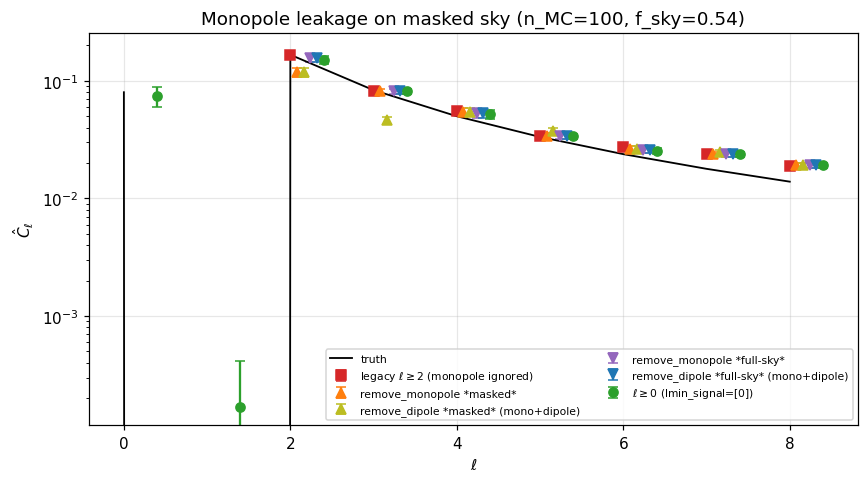

In [8]:
m_l, se_l, _ = _summary(bp_l, err_l)
m_h, se_h, _ = _summary(bp_h, err_h)
m_f, se_f, _ = _summary(bp_f, err_f)
m_h2, se_h2, _ = _summary(bp_h2, err_h2)
m_f2, se_f2, _ = _summary(bp_f2, err_f2)
m_m, se_m, _ = _summary(bp_m, err_m)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    ells_l,
    m_l,
    yerr=se_l,
    fmt="s",
    color="#d62728",
    label=r"legacy $\ell\geq 2$ (monopole ignored)",
    capsize=3,
)
ax.errorbar(
    ells_h + 0.08,
    m_h,
    yerr=se_h,
    fmt="^",
    color="#ff7f0e",
    label=r"remove_monopole *masked*",
    capsize=3,
)
ax.errorbar(
    ells_h2 + 0.16,
    m_h2,
    yerr=se_h2,
    fmt="^",
    color="#bcbd22",
    label=r"remove_dipole *masked* (mono+dipole)",
    capsize=3,
)
ax.errorbar(
    ells_f + 0.24,
    m_f,
    yerr=se_f,
    fmt="v",
    color="#9467bd",
    label=r"remove_monopole *full-sky*",
    capsize=3,
)
ax.errorbar(
    ells_f2 + 0.32,
    m_f2,
    yerr=se_f2,
    fmt="v",
    color="#1f77b4",
    label=r"remove_dipole *full-sky* (mono+dipole)",
    capsize=3,
)
ax.errorbar(
    ells_m + 0.40,
    m_m,
    yerr=se_m,
    fmt="o",
    color="#2ca02c",
    label=r"$\ell\geq 0$ (lmin_signal=[0])",
    capsize=3,
)
ax.plot(ell_axis[:9], cl_true_mono[:9], "k-", lw=1.2, label="truth")
ax.set_yscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\hat{C}_\ell$")
ax.set_title(f"Monopole leakage on masked sky (n_MC={NSIMS}, f_sky={fsky:.2f})")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()

print("Bias (mean − truth) / truth at the inference ells:")
header = (
    f"  {'ell':>3s}  {'legacy':>8s}  {'mono_msk':>9s}  "
    f"{'dip_msk':>9s}  {'mono_full':>10s}  {'dip_full':>9s}  "
    f"{'lmin=0':>8s}"
)
print(header)
for ell in range(2, 7):
    i_l = list(ells_l).index(ell)
    i_h = list(ells_h).index(ell)
    i_h2 = list(ells_h2).index(ell)
    i_f = list(ells_f).index(ell)
    i_f2 = list(ells_f2).index(ell)
    i_m = list(ells_m).index(ell)

    def pct(m_arr, idx):
        return (m_arr[idx] - cl_true_mono[ell]) / cl_true_mono[ell] * 100

    print(
        f"  {ell:>3d}  {pct(m_l, i_l):>+7.1f}%  {pct(m_h, i_h):>+8.1f}%  "
        f"{pct(m_h2, i_h2):>+8.1f}%  {pct(m_f, i_f):>+9.1f}%  "
        f"{pct(m_f2, i_f2):>+8.1f}%  {pct(m_m, i_m):>+7.1f}%"
    )

# Diagnostic: with lmin=0 we also estimate Ĉ_0 and Ĉ_1. We injected
# only the monopole (C_1=0 in cl_true_mono), so Ĉ_1 should sit
# consistent with zero given the Fisher error. Print the values so the
# reader can see "no dipole leakage in the bandpower output" rather
# than be tricked by the log-y plot (truth at ℓ=1 is exactly 0 and
# doesn't render).
i0 = int(np.where(ells_m == 0)[0][0])
i1 = int(np.where(ells_m == 1)[0][0])
print()
print("lmin=0 estimator at the low-ℓ end (truth: C_0=0.08, C_1=0):")
print(
    f"  ell=0:  Ĉ_0 = {m_m[i0]:+.3e} ± {se_m[i0]:.2e} "
    f"(per-real σ = {err_m[i0]:.2e}, sample-mean SE = {se_m[i0]:.2e})"
)
print(f"  ell=1:  Ĉ_1 = {m_m[i1]:+.3e} ± {se_m[i1]:.2e} (per-real σ = {err_m[i1]:.2e})")
print(
    f"  Ĉ_1 vs zero: {m_m[i1] / se_m[i1]:+.2f}σ_mean "
    f"(= {m_m[i1] / err_m[i1]:+.2f}σ on a single realisation)"
)

## What this maps to in the production code

- ``Fisher`` / ``Spectra`` with ``lmin_signal=[2]``, ``lmin=2``: the
  legacy convention; identical to the pre-PR2 behaviour.
- Drop ``lmin`` (and ``lmin_signal[0]``) to 1 for direct dipole
  estimation; drop them to 0 for direct monopole estimation. The
  basis is widened to include the extra modes and the QML solves
  them jointly with the rest of the bandpowers.

In all cases the basis covers ``[min(lmin_signal), lmax_signal]``
and the inference window is ``[lmin, lmax]``; the bands inside the
basis but outside the inference window absorb out-of-window signal
into ``S_fixed`` for the SMW-based inversion (no parameter is
estimated for those ℓ).
